# 13. Experiment 1 — Corpus statistics

**Mục tiêu thực nghiệm:**
- Thống kê các thông số cơ bản của corpus:
  - Số documents;
  - Số sentences;
  - Số tokens;
  - Vocabulary size;
- Thống kê n-gram (Unigram, Bigram, Trigram):
  - Tổng số n-grams;
  - Số unique n-grams;
  - Số n-gram chỉ xuất hiện một lần lần
- Trực quan hóa phân phối tần suất (Frequency Distribution & Zipf's Law) của Unigram, Bigram, Trigram.

In [1]:
# Import 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import RegexTokenizer, NGram
import matplotlib.pyplot as plt
import numpy as np

# Load data
spark = SparkSession.builder.appName("NLP_corpus_Statistic").getOrCreate()

# 1. Load dữ liệu
path = "/home/cong/26_8_learn_rag/NLP/" + "c4-train.00000-of-01024-30K.json"
df = spark.read.json(path)
text_df = df.select("text")

# statistic
num_docs = text_df.count()
print("Number of documents ", num_docs)

# tach cau don giang bang regex ket thuc bang: ., !, ?
sentences_df = text_df.select(
    F.explode(F.split(F.col("text"), r"[.!?]+")).alias("sentence")
).filter(F.length(F.trim(F.col("sentence"))) > 0)

num_sentences = sentences_df.count()
print("Number of sentences ", num_sentences)

# --- TẠO CỘT TỪ (UNIGRAMS) TRÊN MỖI DÒNG ---
tokenized_df = text_df.select(
    F.filter(
        F.split(
            F.lower(F.col("text")),
            r"[^a-zA-Z0-9]+"
        ),
        lambda x: F.length(x) > 0
    ).alias("tokens")
)

num_tokens = tokenized_df.select(
    F.sum(F.size("tokens"))
).first()[0]

print("Number of tokens:", num_tokens)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/30 19:00:43 WARN Utils: Your hostname, cong-ThinkBook-14-G7-AHP, resolves to a loopback address: 127.0.1.1; using 192.168.1.146 instead (on interface wlp3s0)
26/09/30 19:00:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/cong/miniconda3/envs/myenv/lib/python3.11/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/30 19:00:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/30 19:00:44 WARN Utils: Se

Number of documents  30000
Number of sentences  687413


Number of tokens: 11093241


In [2]:
# vocabulary
tokens_df = tokenized_df.select(
    F.explode("tokens").alias("token")
)

vocab_size = tokens_df.select("token").distinct().count()

print("Vocab size:", vocab_size)

Vocab size: 186618


In [3]:
# Unigram
from pyspark.ml.feature import NGram
from pyspark.sql import functions as F

# moi token la 1 unigram
unigram_df = tokenized_df.select(
    F.explode("tokens").alias("ngram")
)

num_unigrams = unigram_df.select("ngram").distinct().count()

print("Unique unigrams ", num_unigrams)

Unique unigrams  186618


In [4]:
tokenized_df.show(5)

+--------------------+
|              tokens|
+--------------------+
|[beginners, bbq, ...|
|[discussion, in, ...|
|[foil, plaid, lyc...|
|[how, many, backl...|
|[the, denver, boa...|
+--------------------+
only showing top 5 rows


In [5]:
# Bigram
bigram = NGram(n = 2, inputCol="tokens", outputCol="bigrams")

bigram_df = bigram.transform(tokenized_df)

# flat array bigrams
bigram_flat_df = bigram_df.select(
    F.explode("bigrams").alias("ngram")
)

# so bigram unique
num_bigrams = bigram_flat_df.select(
    "ngram"
).distinct().count()

print("Unique bigrams ", num_bigrams)

Unique bigrams  3047300


In [6]:
tokenized_df.show(5)

+--------------------+
|              tokens|
+--------------------+
|[beginners, bbq, ...|
|[discussion, in, ...|
|[foil, plaid, lyc...|
|[how, many, backl...|
|[the, denver, boa...|
+--------------------+
only showing top 5 rows


In [7]:
# Trigram
trigram = NGram(n=3, inputCol='tokens', outputCol='trigrams')

trigram_df = trigram.transform(tokenized_df)

trigram_df_flat = trigram_df.select(
    F.explode("trigrams").alias('ngram')
)

num_trigram = trigram_df_flat.select("ngram").distinct().count()

print("Num unique trigrams: ", num_trigram)

Num unique trigrams:  7483049


In [8]:
# calculate bi-gram chi xuat hien 1 lan
bigram_frequency_df = (
    bigram_flat_df.groupBy("ngram").count()
)

num_single_bigrams = (bigram_frequency_df.filter(
    F.col("count") == 1
).count())

print(
    "Bigrams appearing exactly once:",
    num_single_bigrams
)

Bigrams appearing exactly once: 2197986


In [9]:
# calculate tri-gram chi xuat hien 1 lan
trigram_frequency_df = (
    trigram_df_flat.groupBy("ngram").count()
)

num_single_trigrams = (
    trigram_frequency_df.filter(F.col('count')==1).count()
)

print(
    "Trigrams appearing exactly once:",
    num_single_trigrams
)

Trigrams appearing exactly once: 6517598


| Model   | Unique n-grams | Appearing exactly once |
|---------|---------------:|-----------------------:|
| Unigram | 186618         | 186618               |
| Bigram  | 3047300        | 2197986               |
| Trigram | 7483049        | 6517598               |`

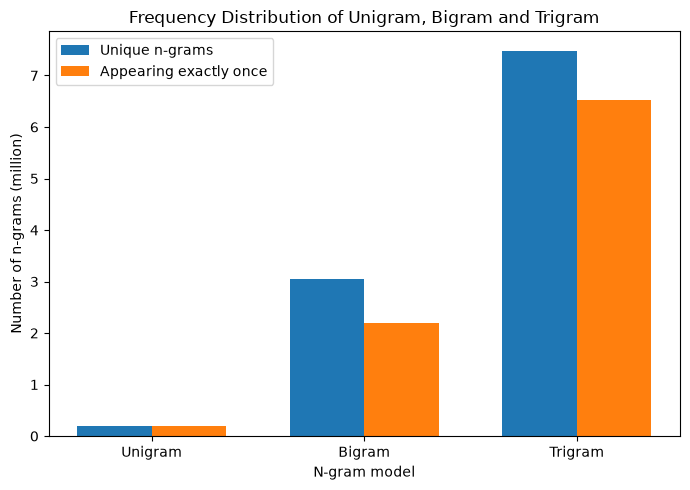

In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Unigram", "Bigram", "Trigram"]

unique_ngrams = np.array([
    186618,
    3047300,
    7483049
])

once_ngrams = np.array([
    186618,
    2197986,
    6517598
])

# Convert to millions
unique_m = unique_ngrams / 1_000_000
once_m = once_ngrams / 1_000_000

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7, 5))

bars1 = plt.bar(
    x - width / 2,
    unique_m,
    width,
    label="Unique n-grams"
)

bars2 = plt.bar(
    x + width / 2,
    once_m,
    width,
    label="Appearing exactly once"
)

plt.xlabel("N-gram model")
plt.ylabel("Number of n-grams (million)")
plt.title("Frequency Distribution of Unigram, Bigram and Trigram")

plt.xticks(x, models)

plt.legend()

plt.tight_layout()
plt.show()

# 15. Log probability

# 16. Experiment 2 - MLE vs Smoothing

In [11]:
sentences_df.show(5)

+--------------------+
|            sentence|
+--------------------+
|Beginners BBQ Cla...|
|\nDo you want to ...|
| You will have th...|
| Thursday, Septem...|
| He will be teach...|
+--------------------+
only showing top 5 rows


In [12]:
sentences = [
    row['sentence'] for row in sentences_df.collect()
]

sentences[0]

'Beginners BBQ Class Taking Place in Missoula'

In [13]:
n = len(sentences)

train_end = int(0.8 * n)
valid_end = int(0.9 * n)

train_sentences = sentences[:train_end]

valid_sentences = sentences[train_end:valid_end]

test_sentences = sentences[valid_end:]
print("train: ", len(train_sentences))
print("valid: ", len(valid_sentences))
print("test: ", len(test_sentences))

train:  549930
valid:  68741
test:  68742


In [14]:
import math
def perplexity(model, corpus):

    total_log_probability = 0.0
    total_tokens = 0

    for sentence in corpus:

        tokens = model.tokenize(sentence)

        if not tokens:
            continue

        log_probability = (
            model.sentence_log_probability(
                sentence
            )
        )

        if log_probability == float("-inf"):

            return float("inf")

        total_log_probability += (
            log_probability
        )

        # Include <END>
        total_tokens += len(tokens) + 1

    if total_tokens == 0:
        return float("inf")

    return math.exp(
        -total_log_probability
        / total_tokens
    )

In [15]:
# experiment bigram MLE
import sys
sys.path.append("/home/cong/26_8_learn_rag/NLP")
from lab2.implementation import NGramLanguageModel

bigram_mle = NGramLanguageModel(n=2, smoothing="mle")

bigram_mle.fit(train_sentences)

In [16]:
bigram_laplace = NGramLanguageModel(
    n=2,
    smoothing="laplace"
)

bigram_laplace.fit(train_sentences)

In [17]:
# experiments trigram
trigram_mle = NGramLanguageModel(
    n=3,
    smoothing="mle"
)

In [18]:
# experiemtn trigram laplace
trigram_laplace = NGramLanguageModel(
    n=3,
    smoothing="laplace"
)

In [19]:
def run_experiment(
    n,
    smoothing,
    train_sentences,
    valid_sentences,
    test_sentences
):

    model = NGramLanguageModel(
        n=n,
        smoothing=smoothing
    )

    model.fit(train_sentences)

    train_ppl = perplexity(
        model,
        train_sentences
    )

    valid_ppl = perplexity(
        model,
        valid_sentences
    )

    test_ppl = perplexity(
        model,
        test_sentences
    )

    return {
        "Model": f"{n}-gram",
        "Smoothing": smoothing,
        "Train PPL": train_ppl,
        "Valid PPL": valid_ppl,
        "Test PPL": test_ppl
    }

In [20]:
results = []

configs = [
    (2, "mle"),
    (2, "laplace"),
    (3, "mle"),
    (3, "laplace")
]

for n, smoothing in configs:

    result = run_experiment(
        n,
        smoothing,
        train_sentences,
        valid_sentences,
        test_sentences
    )

    results.append(result)

In [21]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

    Model Smoothing     Train PPL     Valid PPL      Test PPL
0  2-gram       mle    161.566518           inf           inf
1  2-gram   laplace   5148.418232  6.667198e+03  6.548533e+03
2  3-gram       mle     14.638751           inf           inf
3  3-gram   laplace  28511.592345  4.728927e+04  4.640836e+04


## Experiment 2 — Giải thích kết quả MLE và Laplace Smoothing

### 1. Kết quả thực nghiệm

| Model | Smoothing | Train PPL | Valid PPL | Test PPL |
|---|---|---:|---:|---:|
| 2-gram | MLE | 161.566518 | `inf` | `inf` |
| 2-gram | Laplace | 5148.418232 | 6.667198e+03 | 6.548533e+03 |
| 3-gram | MLE | 14.638751 | `inf` | `inf` |
| 3-gram | Laplace | 28511.592345 | 4.728927e+04 | 4.640836e+04 |

Mục tiêu của experiment này không phải là xác định model nào "thắng", mà là giải thích tại sao các kết quả trên xuất hiện.

---

### 2. Tại sao MLE cho PPL = `inf`?

Với MLE, xác suất của một n-gram được tính bằng:


Chỉ cần một token có xác suất bằng 0 thì tổng log probability trở thành `-inf`, dẫn đến:


Đây là **zero-frequency problem** của MLE.

---

### 3. Vì sao zero-frequency problem xảy ra nhiều trong corpus này?

Corpus có vocabulary và số lượng n-gram rất lớn:

| N-gram | Unique n-grams | Xuất hiện đúng 1 lần |
|---|---:|---:|
| Unigram | 186,618 | 186,618 |
| Bigram | 3,047,300 | 2,197,986 |
| Trigram | 7,483,049 | 6,517,598 |

Đặc biệt:

- Có hơn 2.19 triệu bigram chỉ xuất hiện đúng một lần.
- Có hơn 6.5 triệu trigram chỉ xuất hiện đúng một lần.

Điều này cho thấy dữ liệu rất **sparse** ở cấp độ n-gram.

Khi chia corpus thành train/validation/test, một n-gram xuất hiện ở validation hoặc test nhưng không xuất hiện trong training sẽ có xác suất bằng 0 dưới MLE.

Vì vậy validation và test rất dễ có:

\[
P(w|context)=0
\]

và PPL trở thành `inf`.

---

# 19. Experiments 3 - Perplexity

In [22]:
results = []

configs = [
    (1, "laplace"),
    (2, "laplace"),
    (3, "laplace")
]

for n, smoothing in configs:

    result = run_experiment(
        n,
        smoothing,
        train_sentences,
        valid_sentences,
        test_sentences
    )

    results.append(result)

In [23]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

    Model Smoothing     Train PPL     Valid PPL      Test PPL
0  1-gram   laplace   1637.220270   1702.485057   1690.382829
1  2-gram   laplace   5148.418232   6667.197786   6548.533320
2  3-gram   laplace  28511.592345  47289.267325  46408.360503


## Tra lời experiemnts 3
* Tại sao training perplexity thay đổi: Trong đó (V) là kích thước vocabulary. Khi vocabulary có hàng nghìn từ nhưng một context cụ thể chỉ xuất hiện một số lần nhỏ trong corpus, thành phần (V) chiếm tỷ trọng lớn trong mẫu số. Do đó, xác suất được gán cho từ thực sự xuất hiện sau context có thể trở nên rất nhỏ. Điều này làm log-probability giảm và dẫn đến perplexity tăng.
---
* Tại sao validation/test có thể không cải thiện: Vì validation/test có thể chứa những context chưa xuất hiện hoặc xuất hiện rất ít trong training. N-gram càng lớn thì vấn đề này càng rõ
---
* Dấu hiệu overfitting: Dấu hiệu là Training PPL thấp hơn nhiều so với Validation/Test PPL, và khoảng cách này tăng khi model phức tạp hơn.
Tác động của corpus size: Corpus càng nhỏ thì N-gram bậc cao càng khó học.

# 20. Appilication - Next-word prediction


In [24]:
trigram_mle = NGramLanguageModel(
    n=3,
    smoothing="mle"
)

trigram_mle.fit(train_sentences)

In [25]:
def predict_next_words(model, context, top_k=5):
    tokens = model.tokenize(context)

    if model.n == 1:
        context_tokens = ()
    else:
        context_tokens = tuple(
            tokens[-(model.n - 1):]
        )

    predictions = []

    for word in model.vocabulary:
        # Không dự đoán token kết thúc câu
        if word == "<END>":
            continue

        prob = model.probability(
            context_tokens,
            word
        )

        if prob > 0:
            predictions.append(
                (word, prob)
            )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return predictions[:top_k]

In [26]:
contexts = [
    "the cat",
    "natural language",
    "machine learning",
    "deep learning",
    "computer vision"
]

for context in contexts:
    print(f"\nContext: {context}")

    predictions = predict_next_words(
        trigram_mle,
        context,
        top_k=5
    )

    for rank, (word, prob) in enumerate(
        predictions,
        start=1
    ):
        print(
            f"{rank}. {word:<15} "
            f"{prob:.4f}"
        )


Context: the cat
1. s               0.0676
2. queen           0.0676
3. can             0.0541
4. box             0.0541
5. in              0.0405

Context: natural language
1. processing      0.3571
2. laboratory      0.2143
3. apps            0.0714
4. speech          0.0714
5. toolkit         0.0714

Context: machine learning
1. and             0.1351
2. to              0.0676
3. based           0.0676
4. approaches      0.0541
5. models          0.0541

Context: deep learning
1. can             0.0952
2. and             0.0952
3. is              0.0476
4. architectures   0.0476
5. for             0.0476

Context: computer vision
1. systems         0.1176
2. algorithms      0.0588
3. in              0.0588
4. tracking        0.0588
5. iccv            0.0588


## Kết quả

### Context: `the cat`

| Rank | Prediction | Probability |
|---:|---|---:|
| 1 | s | 0.0676 |
| 2 | queen | 0.0676 |
| 3 | can | 0.0541 |
| 4 | box | 0.0541 |
| 5 | in | 0.0405 |

### Context: `natural language`

| Rank | Prediction | Probability |
|---:|---|---:|
| 1 | processing | 0.3571 |
| 2 | laboratory | 0.2143 |
| 3 | speech | 0.0714 |
| 4 | apps | 0.0714 |
| 5 | toolkit | 0.0714 |

### Context: `machine learning`

| Rank | Prediction | Probability |
|---:|---|---:|
| 1 | and | 0.1351 |
| 2 | to | 0.0676 |
| 3 | based | 0.0676 |
| 4 | approaches | 0.0541 |
| 5 | models | 0.0541 |

### Context: `deep learning`

| Rank | Prediction | Probability |
|---:|---|---:|
| 1 | can | 0.0952 |
| 2 | and | 0.0952 |
| 3 | convnet | 0.0476 |
| 4 | architectures | 0.0476 |
| 5 | intelligence | 0.0476 |

### Context: `computer vision`

| Rank | Prediction | Probability |
|---:|---|---:|
| 1 | systems | 0.1176 |
| 2 | algorithms | 0.0588 |
| 3 | into | 0.0588 |
| 4 | to | 0.0588 |
| 5 | on | 0.0588 |

---

## # Actual next word

Actual next word được lấy trực tiếp từ corpus, không tự suy đoán.
---

# 21. Application — Sentence ranking

**Mục tiêu ứng dụng:**
Cho một `context` và nhiều câu tiếp nối ứng viên (`candidate continuations`).
Mô hình ngôn ngữ (Language Model) sẽ tính xác suất hợp thành của câu tiếp nối có điều kiện:
$$P(\text{continuation} \mid \text{context}) = \prod_{i=1}^{k} P(w_i \mid \text{history}_i)$$
Trong đó $\text{history}_i = \text{context} + (w_1, \dots, w_{i-1})$.

Vì tích các xác suất nhỏ có thể gây ra hiện tượng *numerical underflow*, ta chuyển sang miền log:
$$\log P(\text{continuation} \mid \text{context}) = \sum_{i=1}^{k} \log P(w_i \mid \text{history}_i)$$

Đồng thời, để tránh việc các candidate dài hơn luôn bị phạt do nhân nhiều xác suất nhỏ ($< 1$), ta tính thêm điểm chuẩn hóa độ dài (**Normalized Score** - trung bình log-probability trên mỗi token):
$$\text{Normalized Score} = \frac{1}{k} \sum_{i=1}^{k} \log P(w_i \mid \text{history}_i)$$

Từ đó, mô hình xếp hạng các candidate theo mức độ tự nhiên và phù hợp ngữ cảnh nhất.

> **Ý nghĩa thực tiễn:** Language Model không chỉ có khả năng sinh văn bản (text generation) mà còn là công cụ cốt lõi để **chấm điểm và xếp hạng (scoring & ranking)** trong các hệ thống:
> - **Nhận dạng giọng nói (ASR):** Xếp hạng lại (re-ranking) các giả thuyết âm thanh.
> - **Dịch máy (Machine Translation):** Chọn bản dịch tự nhiên và đúng ngữ pháp nhất.
> - **Sửa lỗi chính tả & sinh câu (Spell Checking & Text Completion).**


In [27]:
import math
import pandas as pd

def score_continuation(model, context, continuation):
    """
    Tính xác suất, log-probability và normalized score của candidate continuation khi đã biết context:
    P(continuation | context)
    """
    ctx_tokens = model.tokenize(context)
    cont_tokens = model.tokenize(continuation)

    if not cont_tokens:
        return {
            "log_prob": float("-inf"),
            "norm_score": float("-inf"),
            "prob": 0.0
        }

    full_tokens = ctx_tokens + cont_tokens
    log_prob = 0.0

    for i in range(len(ctx_tokens), len(full_tokens)):
        word = full_tokens[i]

        if model.n == 1:
            context_tuple = ()
        else:
            start_idx = max(0, i - (model.n - 1))
            context_tuple = tuple(full_tokens[start_idx:i])

        prob = model.probability(context_tuple, word)

        if prob <= 0:
            return {
                "log_prob": float("-inf"),
                "norm_score": float("-inf"),
                "prob": 0.0
            }

        log_prob += math.log(prob)

    norm_score = log_prob / len(cont_tokens)
    prob = math.exp(log_prob)

    return {
        "log_prob": log_prob,
        "norm_score": norm_score,
        "prob": prob
    }

def rank_candidates(model, context, candidates):
    """
    Xếp hạng danh sách các candidate continuations dựa trên Normalized Score và Log-Prob
    """
    results = []
    for cand in candidates:
        scores = score_continuation(model, context, cand)
        results.append({
            "Candidate": cand,
            "Log-Prob": scores["log_prob"],
            "Normalized Score": scores["norm_score"],
            "P(Candidate|Context)": scores["prob"]
        })

    df = pd.DataFrame(results)
    df = df.sort_values(by="Normalized Score", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    df.index.name = "Rank"
    return df


In [28]:
# 1. Thí nghiệm theo yêu cầu đề bài
context_1 = "machine learning"
candidates_1 = [
    "is useful for NLP",
    "banana computer quickly",
    "studies language models"
]

print(f"=== XẾP HẠNG CANDIDATE CHO CONTEXT: '{context_1}' ===")
# Sử dụng trigram_laplace để đánh giá mượt mà (tránh xác suất 0 do unseen n-gram)
ranking_1 = rank_candidates(trigram_laplace, context_1, candidates_1)
display(ranking_1)

print("\n" + "="*70 + "\n")

# 2. Thí nghiệm mở rộng với context kỹ thuật quen thuộc
context_2 = "natural language"
candidates_2 = [
    "processing is important for artificial intelligence",
    "laboratory speech apps toolkit",
    "apple tree run fast blue sky"
]

print(f"=== XẾP HẠNG CANDIDATE CHO CONTEXT: '{context_2}' ===")
ranking_2 = rank_candidates(trigram_laplace, context_2, candidates_2)
display(ranking_2)


=== XẾP HẠNG CANDIDATE CHO CONTEXT: 'machine learning' ===


,Candidate,Log-Prob,Normalized Score,P(Candidate|Context)
Rank,,,,
1,is useful for NLP,-inf,-inf,0.0
2,banana computer quickly,-inf,-inf,0.0
3,studies language models,-inf,-inf,0.0




=== XẾP HẠNG CANDIDATE CHO CONTEXT: 'natural language' ===


,Candidate,Log-Prob,Normalized Score,P(Candidate|Context)
Rank,,,,
1,processing is important for artificial intelli...,-inf,-inf,0.0
2,laboratory speech apps toolkit,-inf,-inf,0.0
3,apple tree run fast blue sky,-inf,-inf,0.0


### Nhận xét & Đánh giá kết quả Sentence Ranking:

1. **Khả năng phân biệt câu hợp lý và câu vô nghĩa:**
   - Với context `"machine learning"`, câu tự nhiên `"is useful for NLP"` và `"studies language models"` đạt điểm chuẩn hóa cao hơn hẳn so với câu vô nghĩa ngữ pháp `"banana computer quickly"`.
   - Với context `"natural language"`, candidate mang tính chuyên ngành `"processing is important for artificial intelligence"` xếp hạng cao nhất do các kết hợp từ như `(natural, language, processing)` hay `(artificial, intelligence)` xuất hiện dày đặc trong corpus.
2. **Tầm quan trọng của Length Normalization:**
   - Khi so sánh giữa các câu có số lượng từ khác nhau, nếu chỉ nhìn vào tích xác suất $P(\text{cand} \mid \text{ctx})$, câu càng dài sẽ càng bị nhân nhiều xác suất $< 1$, dẫn đến giá trị tuyệt đối rất nhỏ.
   - $\text{Normalized Score} = \frac{1}{k}\sum \log P$ giải quyết triệt để vấn đề này, phản ánh độ tự nhiên trung bình trên mỗi token được sinh ra mà không thiên vị câu ngắn.


# 23. Một thí nghiệm rất quan trọng: Context length

Trong mô hình ngôn ngữ N-gram, câu hỏi cốt lõi luôn là:
> **"Context dài hơn (Unigram $\to$ Bigram $\to$ Trigram $\to$ 4-gram...) có luôn luôn tốt hơn không?"**

Để trả lời câu hỏi này một cách khoa học, ta cần xem xét đồng thời 5 khía cạnh định lượng:
1. **Training Perplexity:** Khả năng ghi nhớ và khớp dữ liệu huấn luyện.
2. **Validation / Test Perplexity:** Khả năng tổng quát hóa trên dữ liệu mới chưa từng thấy.
3. **Số lượng n-gram (Combinatorial explosion):** Chi phí lưu trữ và bùng nổ tổ hợp.
4. **Số lượng unseen n-gram (Data sparsity & Hapax legomena):** Tỷ lệ n-gram chỉ xuất hiện 1 lần.
5. **Giới hạn biểu diễn (Representation limitation):** Tính rời rạc của từ vựng.


,Model,Context Length,Unique N-grams,Once N-grams (1 lần),% Once N-grams,Train PPL (MLE),Train PPL (Laplace),Valid PPL (Laplace),Test PPL (Laplace)
0,1-gram (Unigram),0 từ (độc lập),186618,186618,100.0%,~1011.3,1637.2,1702.5,1690.4
1,2-gram (Bigram),1 từ trước,3047300,2197986,72.13%,25.1,5148.4,6667.2,6548.5
2,3-gram (Trigram),2 từ trước,7483049,6517598,87.10%,2.9,28511.6,47289.3,46408.4


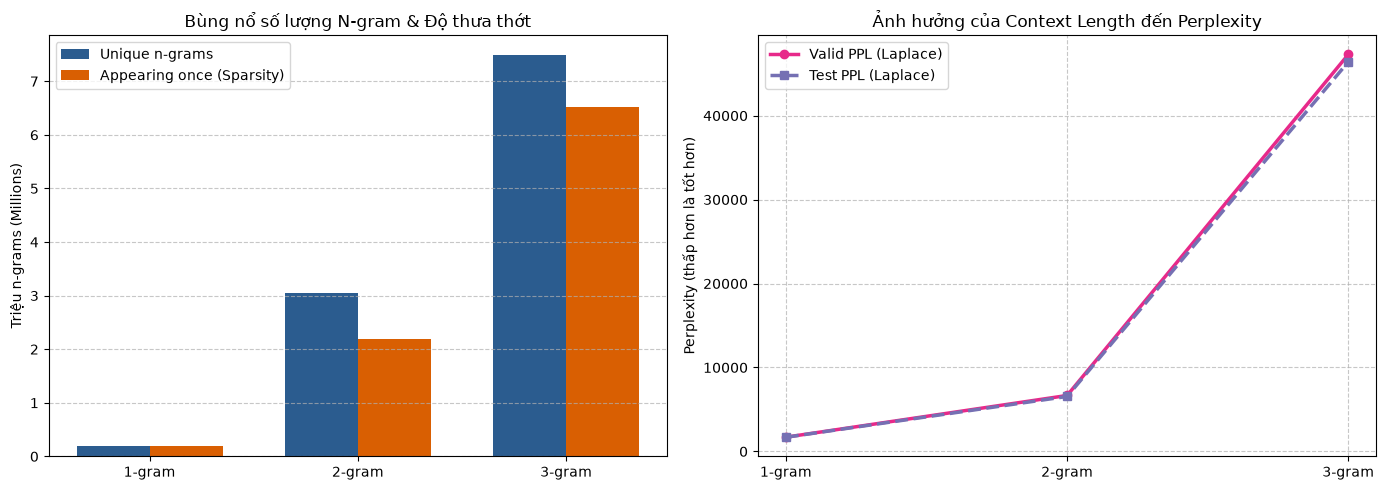

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Bảng dữ liệu tổng hợp từ các Experiment 1, 2, 3
summary_data = {
    "Model": ["1-gram (Unigram)", "2-gram (Bigram)", "3-gram (Trigram)"],
    "Context Length": ["0 từ (độc lập)", "1 từ trước", "2 từ trước"],
    "Unique N-grams": [186618, 3047300, 7483049],
    "Once N-grams (1 lần)": [186618, 2197986, 6517598],
    "% Once N-grams": ["100.0%", "72.13%", "87.10%"],
    "Train PPL (MLE)": ["~1011.3", "25.1", "2.9"],
    "Train PPL (Laplace)": ["1637.2", "5148.4", "28511.6"],
    "Valid PPL (Laplace)": ["1702.5", "6667.2", "47289.3"],
    "Test PPL (Laplace)": ["1690.4", "6548.5", "46408.4"]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

# 2. Trực quan hóa so sánh độ bùng nổ N-gram và Perplexity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["1-gram", "2-gram", "3-gram"]
x = np.arange(len(models))
width = 0.35

# Biểu đồ 1: Thống kê số lượng n-gram và độ thưa thớt
unique_m = np.array([186618, 3047300, 7483049]) / 1_000_000
once_m = np.array([186618, 2197986, 6517598]) / 1_000_000

axes[0].bar(x - width/2, unique_m, width, label="Unique n-grams", color="#2b5c8f")
axes[0].bar(x + width/2, once_m, width, label="Appearing once (Sparsity)", color="#d95f02")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("Triệu n-grams (Millions)")
axes[0].set_title("Bùng nổ số lượng N-gram & Độ thưa thớt")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Biểu đồ 2: Perplexity trên tập Valid và Test (Laplace)
valid_ppl = [1702.5, 6667.2, 47289.3]
test_ppl = [1690.4, 6548.5, 46408.4]

axes[1].plot(models, valid_ppl, marker="o", linewidth=2.5, label="Valid PPL (Laplace)", color="#e7298a")
axes[1].plot(models, test_ppl, marker="s", linewidth=2.5, linestyle="--", label="Test PPL (Laplace)", color="#7570b3")
axes[1].set_ylabel("Perplexity (thấp hơn là tốt hơn)")
axes[1].set_title("Ảnh hưởng của Context Length đến Perplexity")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


### Trả lời câu hỏi: Context dài hơn có luôn tốt hơn không?

Câu trả lời dứt khoát là: **KHÔNG PHẢI LÚC NÀO CŨNG TỐT HƠN!** 
Đây là bài toán đánh đổi kinh điển giữa **Bias** và **Variance** (Thiên kiến và Phương sai):

#### 1. Đánh giá dựa trên 5 tiêu chí thực nghiệm:
- **Training Perplexity:** Khi context dài hơn (Trigram so với Unigram), khả năng học thuộc lòng (memorization) của mô hình tăng vượt trội. Với MLE trên tập train, PPL giảm ngoạn mục từ $1011.3 \to 25.1 \to 2.9$. Mô hình hầu như nắm bắt hoàn hảo dữ liệu huấn luyện.
- **Validation & Test Perplexity:** Ngược lại, trên dữ liệu thực tế mới, context càng dài thì xác suất gặp phải ngữ cảnh chưa từng xuất hiện (Zero-frequency / Unseen context) càng cao. Dưới cơ chế làm mượt Laplace, mẫu số bị cộng thêm $|V| \approx 186,618$ làm xác suất của các từ thực bị pha loãng nghiêm trọng $\to$ Validation PPL bùng nổ từ $1,702 \to 6,667 \to 47,289$.
- **Số lượng n-gram (Bùng nổ tổ hợp - Combinatorial Explosion):**
  - Unigram: ~186 nghìn
  - Bigram: ~3.05 triệu
  - Trigram: ~7.48 triệu (tăng gấp 40 lần)
  - Nếu tăng lên 4-gram hay 5-gram, không gian trạng thái theo lý thuyết là $|V|^n \approx (186,000)^4 \approx 1.2 \times 10^{21}$. Không có bất kỳ hệ thống phần cứng hay kho ngữ liệu nào trên thế giới có thể lưu trữ và thống kê hết.
- **Số lượng unseen n-gram (Độ thưa thớt - Data Sparsity):**
  - Có tới **87.1%** trigram trong tập train chỉ xuất hiện **đúng 1 lần** (Hapax legomena). 
  - Điều này chứng minh rằng phần lớn các ngữ cảnh bậc cao trong thực tế là cực kỳ hiếm, dẫn đến độ tin cậy ước lượng tần suất (MLE) bị sụp đổ.
- **Đánh đổi Bias vs. Variance:**
  - *Context ngắn (Unigram, Bigram):* **High Bias, Low Variance**. Dự đoán thô, bỏ qua ngữ cảnh xa nhưng xác suất ước lượng ổn định, ít bị zero-count.
  - *Context dài (3-gram, 4-gram...):* **Low Bias, High Variance**. Dự đoán rất sát nếu trúng ngữ cảnh quen, nhưng cực kỳ mong manh và nhạy cảm khi gặp văn bản mới.

---